# Case NPS Preditivo - Análise Exploratória


Com o crescimento acelerado do e-commerce nacional, temos o cenário de
uma empresa que passou a lidar com um volume cada vez maior de pedidos, entregas
e interações com clientes. Esse crescimento trouxe ganhos importantes de escala,
mas também revelou desafios relevantes na experiência do cliente, especialmente
refletidos na alta variabilidade do Net Promoter Score (NPS) entre diferentes perfis de
consumidores. A área de Experiência do Cliente percebeu que, mesmo com
indicadores operacionais aparentemente semelhantes, alguns clientes se tornam
promotores da marca, enquanto outros se tornam detratores.

Essa diferença levanta uma questão central para o negócio: **quais fatores
operacionais realmente influenciam a satisfação do cliente e como a empresa
pode agir de forma proativa para melhorar a experiência antes mesmo da
aplicação da pesquisa de NPS?**

Atualmente, o NPS é coletado apenas após o encerramento da jornada de
compra, o que limita a capacidade da empresa de antecipar problemas, priorizar
ações corretivas e atuar de forma preventiva. Nesse contexto, surge a necessidade de transformar dados operacionais, como informações de pedidos, logística e atendimento, em insights acionáveis, capazes de orientar decisões estratégicas e operacionais.

## Pacotes

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Leitura dos dados

In [ ]:
dados = pd.read_csv("https://raw.githubusercontent.com/braga0m/TechChallenge1/refs/heads/main/dados/dados_ecommerce_tratado.csv")

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [ ]:
dados.describe().round(2)

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,complaints
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94,0.99
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38,0.10
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70,1.00
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80,1.00
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80,1.00
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00,1.00


In [ ]:
dados[["nps_score", "nps_categoria"]].query("nps_score > 6")

,nps_score,nps_categoria
0,6.9,Detratores
4,6.1,Detratores
8,6.2,Detratores
11,7.0,Neutros
22,10.0,Promotores
...,...,...
2481,8.2,Neutros
2489,8.7,Neutros
2493,8.5,Neutros
2497,7.4,Neutros


## Análise Exploratória

O Net Promoter Score (NPS) é uma métrica de lealdade e satisfação do cliente.


NPS = (Promotores – Detratores) / Número total de respondentes.  

https://fia.com.br/blog/net-promoter-score-nps/  

https://www.mercadopago.com.br/blog/nps

Em uma escala de 0 a 10, o quanto você indicaria nosso serviço para um amigo?

*   **Promotores:** atribuem nota 9 ou 10, revelando altas chances de recomendar sua empresa.  

*   **Neutros:** dão nota 7 ou 8. Sua relação com a companhia é regular, mas existem pontos a melhorar.  

*   **Detratores:** nota de 0 a 6. Estão descontentes com seu produto, serviço ou atendimento, o que pode levá-los a fazer uma propaganda negativa.






In [ ]:
#### agrupando e agregando dados de acordo com o categoria nps
x = dados.groupby("nps_categoria").size().reset_index(name="n")

x["prop"] = 100*round(x["n"] / 2500, 3)

x = x.rename(columns={"nps_classe":"Tipo", "prop":"%"})

x

,nps_categoria,n,%
0,Detratores,2109,84.4
1,Neutros,281,11.2
2,Promotores,110,4.4


Cálculo do NPS de uma empresa.

**(Promotores – Detratores)/(Número total de respondentes)**  


De acordo com o blog do Mercado Pago:

Excelente – NPS entre 75 e 100  
Muito bom – NPS entre 50 e 74  
Razoável – NPS entre 0 e 49  
Ruim – NPS entre -100 e -1

In [ ]:
nps_empresa = (x["n"][2] - x["n"][0])/2500
nps_empresa.astype(float)

np.float64(-0.7996)

### NPS SCORE

Distribuição do NPS score.
Nota-se uma assimetria e concentração mais a esquerda - indicativo de que os clientes estão mais insatisfeitos, no geral.

Observe que 84.36% deram uma nota inferior a sete no quesito de satisfação.


In [ ]:
#### Tabela de frequência relativa para nps_score por faixa

# Definindo os limites das faixas (bins)
bins = list(range(10)) + [dados['nps_score'].max() + 0.001] # Bins for 0 to 9, and the last bin for 9 to max

# Definindo os rótulos para as faixas (9 labels for 9 intervals, and 1 for 9+)
labels = [f'{i} - {i+1}' for i in range(9)] + ['9+']

# Criando a nova coluna com as categorias de nps_score
dados['nps_score_faixa'] = pd.cut(dados['nps_score'], bins=bins, labels=labels, right=False)

# Calculando a frequência absoluta, relativa e acumulada relativa
freq_table = dados['nps_score_faixa'].value_counts(dropna=False).sort_index().reset_index()
freq_table.columns = ['NPS Score Faixa', 'Frequência Absoluta']
freq_table['Frequência Relativa (%)'] = (freq_table['Frequência Absoluta'] / len(dados)) * 100
freq_table['Frequência Relativa (%)'] = freq_table['Frequência Relativa (%)'].round(3)
freq_table['Frequência Relativa Acumulada (%)'] = freq_table['Frequência Relativa (%)'].cumsum().round(3)

display(freq_table)

,NPS Score Faixa,Frequência Absoluta,Frequência Relativa (%),Frequência Relativa Acumulada (%)
0,0 - 1,272,10.88,10.88
1,1 - 2,191,7.64,18.52
2,2 - 3,286,11.44,29.96
3,3 - 4,339,13.56,43.52
4,4 - 5,378,15.12,58.64
5,5 - 6,351,14.04,72.68
6,6 - 7,292,11.68,84.36
7,7 - 8,173,6.92,91.28
8,8 - 9,108,4.32,95.60
9,9+,110,4.40,100.00


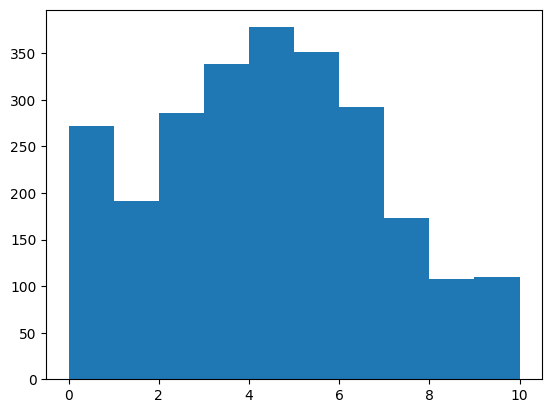

In [ ]:
#### comportamento do nps - histograma
plt.hist(dados["nps_score"])
plt.show()

### Dias de atraso


In [ ]:
###
dados["delay_categoria"] = dados["delivery_delay_days"].case_when([
    (dados["delivery_delay_days"] == 0, "0"),
    (dados["delivery_delay_days"] == 1, "1"),
    (dados["delivery_delay_days"] == 2, "2"),
    (dados["delivery_delay_days"] == 3, "3"),
    (dados["delivery_delay_days"].isin([4,5,6,7,8]), "4+"),
])

###
dados["delay_categoria"] = pd.Categorical(
    dados["delay_categoria"],
    categories=["0", "1", "2", "3", "4+"],
    ordered=True
)

<Axes: xlabel='delay_categoria', ylabel='nps_score'>

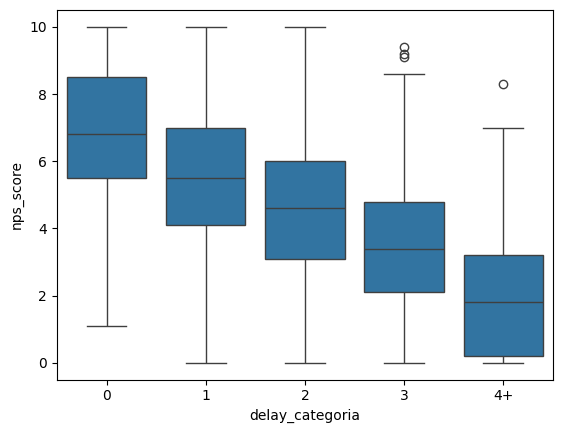

In [ ]:
##
sns.boxplot(data=dados,  x = "delay_categoria", y="nps_score")

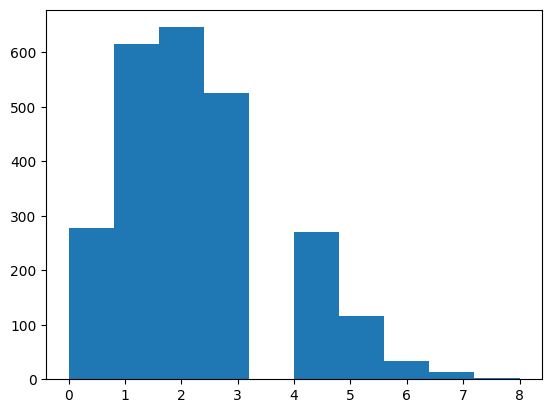

In [ ]:
#### comportamento do nps - histograma
plt.hist(dados["delivery_delay_days"])
plt.show()

In [ ]:
#### Tabela de frequência para delivery_delay_days

# Calculando a frequência absoluta
freq_table_delay = dados['delivery_delay_days'].value_counts(dropna=False).sort_index().reset_index()
freq_table_delay.columns = ['Delivery Delay Days', 'Frequência Absoluta']

# Calculando a frequência relativa
freq_table_delay['Frequência Relativa (%)'] = (freq_table_delay['Frequência Absoluta'] / len(dados)) * 100
freq_table_delay['Frequência Relativa (%)'] = freq_table_delay['Frequência Relativa (%)'].round(3)

# Calculando a frequência relativa acumulada
freq_table_delay['Frequência Relativa Acumulada (%)'] = freq_table_delay['Frequência Relativa (%)'].cumsum().round(3)

display(freq_table_delay)

,Delivery Delay Days,Frequência Absoluta,Frequência Relativa (%),Frequência Relativa Acumulada (%)
0,0,277,11.08,11.08
1,1,615,24.60,35.68
2,2,646,25.84,61.52
3,3,525,21.00,82.52
4,4,270,10.80,93.32
5,5,116,4.64,97.96
6,6,34,1.36,99.32
7,7,14,0.56,99.88
8,8,3,0.12,100.00


### Número de reclamações

<Axes: xlabel='complaints', ylabel='nps_score'>

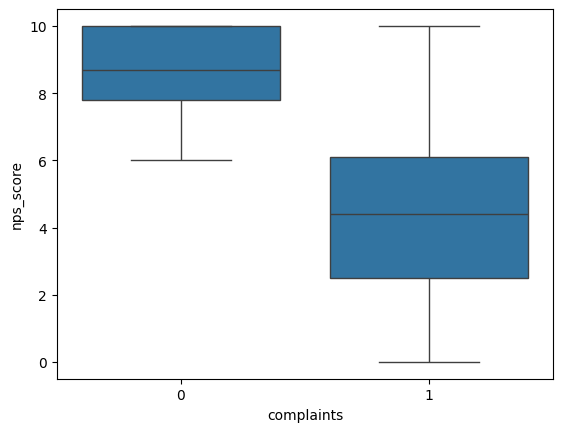

In [ ]:
##
sns.boxplot(data=dados,  x = "complaints", y="nps_score")

In [ ]:
#### Tabela de frequência para delivery_delay_days

# Calculando a frequência absoluta
freq_table_complaints_count = dados['complaints_count'].value_counts(dropna=False).sort_index().reset_index()
freq_table_complaints_count.columns = ['Número de reclamações', 'Frequência Absoluta']

# Calculando a frequência relativa
freq_table_complaints_count['Frequência Relativa (%)'] = (freq_table_complaints_count['Frequência Absoluta'] / len(dados)) * 100
freq_table_complaints_count['Frequência Relativa (%)'] = freq_table_complaints_count['Frequência Relativa (%)'].round(3)

# Calculando a frequência relativa acumulada
freq_table_complaints_count['Frequência Relativa Acumulada (%)'] = freq_table_complaints_count['Frequência Relativa (%)'].cumsum().round(3)

display(freq_table_complaints_count)

,Número de reclamações,Frequência Absoluta,Frequência Relativa (%),Frequência Relativa Acumulada (%)
0,0,23,0.92,0.92
1,1,122,4.88,5.80
2,2,277,11.08,16.88
3,3,507,20.28,37.16
4,4,600,24.00,61.16
5,5,444,17.76,78.92
6,6,266,10.64,89.56
7,7,169,6.76,96.32
8,8,63,2.52,98.84
9,9,16,0.64,99.48


### Matriz de correlação

In [ ]:
##### variáveis numéricas
cols_operacionais = [
    'delivery_delay_days',
    'complaints_count',
    'customer_service_contacts',
    'resolution_time_days',
    'freight_value',
    'order_value',
    'csat_internal_score',
    'repeat_purchase_30d',
    'nps_score']

#### matriz de correlação
corr_matrix = dados[cols_operacionais].corr().round(2)

#### heatmap com a matriz de correlação
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    corr_matrix,
    annot=True,          # exibe os valores dentro das células
    fmt='.2f',           # duas casas decimais
    cmap='RdYlGn',       # vermelho (negativo) → amarelo → verde (positivo)
    center=0,            # centro da paleta em zero
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 9})

NameError: name 'dados' is not defined

### Rascunhos e Testes

<Axes: ylabel='nps_score'>

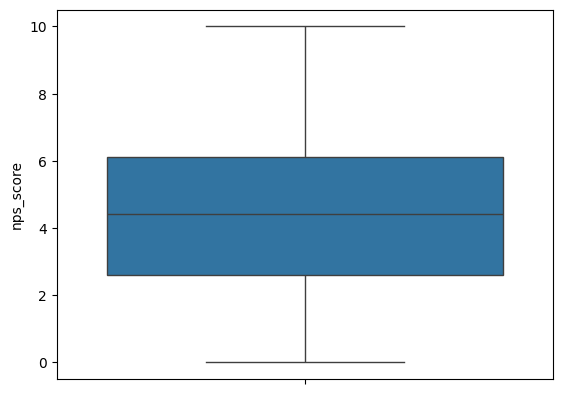

In [ ]:
####
sns.boxplot(data=dados, y="nps_score")

<Axes: xlabel='repeat_purchase_30d', ylabel='nps_score'>

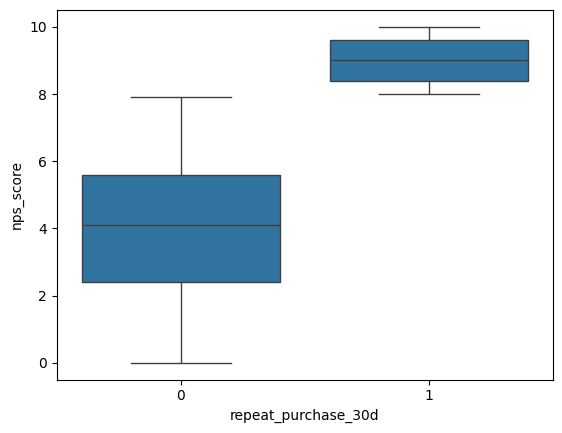

In [ ]:
####reafirma a teoria de que um nps (satisfação) alto está relacionado a recompra
sns.boxplot(data=dados, x="repeat_purchase_30d", y="nps_score")

<Axes: xlabel='customer_region', ylabel='nps_score'>

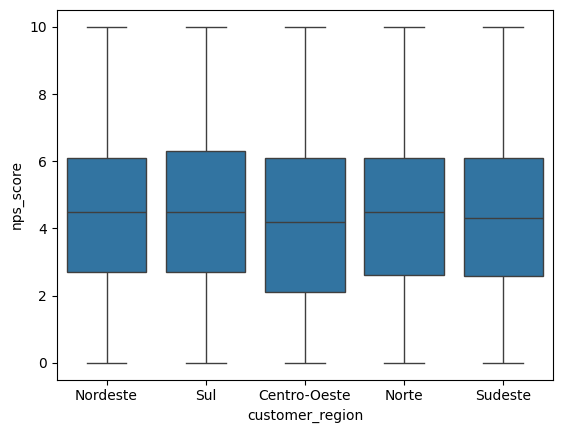

In [ ]:
#### região não aparenta ser um fator que impacta a satisfação do cliente
sns.boxplot(data=dados, x="customer_region", y="nps_score")